<a href="https://colab.research.google.com/github/gamal-zayed/Quantized-Low-Rank-Adaptation-Parameter-Efficient-Fine-Tuning/blob/main/Rank_Ablation_Collateral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q trl peft bitsandbytes evaluate accelerate rouge_score bert_score matplotlib seaborn
#nTrain = 5000

Cell 1: Infrastructure Setup (Run Once)
-

In [ ]:
# %% ==================== CELL 1: SETUP ====================
from google.colab import drive
drive.mount('/content/drive')

import os, gc, json, time, torch
import pandas as pd
import numpy as np
from collections import Counter
from transformers import AutoConfig, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset
import evaluate
from tqdm import tqdm

# Experiment 3 Specifications
MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"
#TARGET_MODULES = ["q_proj", "v_proj"] # Standard Attention Layers as per Experiment 3
TARGET_MODULES = ["qkv_proj"]  # This targets the core Attention layer for Experiment 3
RANKS = [4, 8, 16, 32, 64]
SEEDS = [42, 2026] # Two random seeds for mean ± std deviation stability

# Dedicated persistent experiment folder
DRIVE_ROOT = "/content/drive/MyDrive/exp_3_rank_ablation"
os.makedirs(DRIVE_ROOT, exist_ok=True)

# Parameter formula verification
PER_LAYER_COEF = {"qkv_proj": 7680, "o_proj": 6144, "gate_up_proj": 19456, "down_proj": 11264}
#PER_LAYER_COEF = {"q_proj": 3072, "v_proj": 3072}
NUM_LAYERS = 32
def predicted_trainable_params(target_modules, r):
    return sum(PER_LAYER_COEF[m] for m in target_modules) * NUM_LAYERS * r

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=False)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

raw_dataset = load_dataset("keivalya/MedQuad-MedicalQnADataset", split="train")

def make_splits(seed, n_train=5000): #WAS 1500
    shuffled = raw_dataset.shuffle(seed=seed)
    return shuffled.select(range(n_train)), shuffled.select(range(5000, 5500))

def formatting_prompts_func(examples):
    q_types = examples.get('qtype', [''] * len(examples[list(examples.keys())[0]]))
    questions = examples.get('Question', examples.get('question'))
    answers = examples.get('Answer', examples.get('answer'))
    texts = []
    for qt, q, a in zip(q_types, questions, answers):
        messages = [
            {"role": "system", "content": "You are a knowledgeable medical assistant. Answer the patient's question clearly and accurately."},
            {"role": "user", "content": f"Context: {qt}. Question: {q}"},
            {"role": "assistant", "content": a}
        ]
        texts.append(tokenizer.apply_chat_template(messages, tokenize=False))
    return {"text": texts}

QUALITATIVE_PROBES = [
    "What is the first-line treatment for hypertension in a diabetic patient?",
    "What are the symptoms of type 2 diabetes?",
    "What causes rheumatoid arthritis?",
]

# # --- Global Interceptor to prevent DeBERTa Tokenizer Overflow Errors ---
# from transformers import AutoTokenizer as _AutoTokenizer
# _orig_from_pretrained = _AutoTokenizer.from_pretrained.__func__
# def _clamped_from_pretrained(cls, *args, **kwargs):
#     tok = _orig_from_pretrained(cls, *args, **kwargs)
#     if getattr(tok, "model_max_length", 0) > 100000:
#         print(f"Clamping absurd model_max_length -> 512 for {args[0] if args else kwargs.get('pretrained_model_name_or_path')}")
#         tok.model_max_length = 512
#     return tok
# _AutoTokenizer.from_pretrained = classmethod(_clamped_from_pretrained)


# --- Global Interceptor to prevent DeBERTa Tokenizer Overflow Errors ---
from transformers import AutoTokenizer as _AutoTokenizer

# 🎯 Check if we have already wrapped this function before doing it again!
if not hasattr(_AutoTokenizer, "_is_clamped_interceptor"):
    _orig_from_pretrained = _AutoTokenizer.from_pretrained.__func__

    def _clamped_from_pretrained(cls, *args, **kwargs):
        tok = _orig_from_pretrained(cls, *args, **kwargs)
        if getattr(tok, "model_max_length", 0) > 100000:
            print(f"Clamping absurd model_max_length -> 512 for {args[0] if args else kwargs.get('pretrained_model_name_or_path')}")
            tok.model_max_length = 512
        return tok

    _AutoTokenizer.from_pretrained = classmethod(_clamped_from_pretrained)
    _AutoTokenizer._is_clamped_interceptor = True # Mark it as wrapped

print("Cell 1 setup complete. Infrastructure ready for Rank Ablation")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Cell 1 setup complete. Infrastructure ready for Rank Ablation


Cell 2: Automated Training Matrix (Persistent Checkpoints)
-

In [ ]:
# %% ==================== CELL 2: TRAINING LOOP ====================

def train_rank_configuration(rank, seed):
    run_name = f"rank_{rank}_seed_{seed}"
    out_dir = os.path.join(DRIVE_ROOT, run_name)
    meta_path = os.path.join(out_dir, "meta.json")

    if os.path.exists(meta_path):
        print(f"SKIPPING: {run_name} already completed.")
        return

    print(f"\n{'='*60}\nTRAINING: Rank={rank} | Seed={seed}\n{'='*60}")

    from accelerate.state import AcceleratorState, PartialState
    AcceleratorState._reset_state()
    PartialState._reset_state()


    train_dataset, val_dataset = make_splits(seed, n_train=5000)  #make_splits(seed, nTrain) #Was train_dataset, val_dataset = make_splits(seed, n_train=1500)
    train_dataset = train_dataset.map(formatting_prompts_func, batched=True)
    val_dataset = val_dataset.map(formatting_prompts_func, batched=True)

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
    )

    config = AutoConfig.from_pretrained(MODEL_ID)
    config._attn_implementation = "sdpa"

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, config=config, quantization_config=bnb_config,
        device_map={"": 0}, trust_remote_code=False, torch_dtype=torch.float16,
    )
    base_model.config.use_cache = False
    base_model = prepare_model_for_kbit_training(base_model, use_gradient_checkpointing=True) # 🎯 Explicitly tell PEFT to use checkpointing
    base_model.gradient_checkpointing_enable() # 🎯 Turn it on in the base model
    #base_model = prepare_model_for_kbit_training(base_model)

    peft_config = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        target_modules=TARGET_MODULES,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )

    model = get_peft_model(base_model, peft_config)
    trainable_actual = sum(p.numel() for p in model.parameters() if p.requires_grad)

    training_config = SFTConfig(
        output_dir=out_dir,
        dataset_text_field="text",
        max_length=384,
        packing=False,  # INTENTIONALLY KEPT FALSE
        per_device_train_batch_size=4,       # Optimized for free tier stability
        gradient_accumulation_steps=2,       # Combined with batch size = 8

        gradient_checkpointing=True, # 🎯 Passes checkpointing commands straight to the SFTTrainer engine

        learning_rate=2e-4,
        num_train_epochs=1, #WERE 3 EPOCH FOR TIME CONSTRAINTS
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="steps",
        save_steps=100, #Was 300, # was 50, # Persistent checkpoint saving to Google Drive every 50 steps
        fp16=False, #True, # WAS SET False, TRUE AS WE ALREADY SET torch_dtype=torch.float16 ABOVE
        bf16=False,
        optim="paged_adamw_8bit",
        seed=seed,
        report_to=[],
    )

    trainer = SFTTrainer(
        model=model, train_dataset=train_dataset, eval_dataset=val_dataset,
        processing_class=tokenizer, args=training_config,
    )

    # Core Persistent Resume Logic
    resume = os.path.isdir(out_dir) and any(d.startswith("checkpoint-") for d in os.listdir(out_dir))
    if resume:
        print(f"--> Found persistent checkpoint in Drive for {run_name}. Resuming training...")

    t0 = time.time()
    trainer.train(resume_from_checkpoint=resume)
    wall_time = time.time() - t0
    val_loss = trainer.evaluate()["eval_loss"]

    model.save_pretrained(out_dir)
    tokenizer.save_pretrained(out_dir)

    meta = {
        "rank": rank, "seed": seed, "target_modules": TARGET_MODULES,
        "trainable_params_actual": trainable_actual,
        "wall_time_sec": wall_time, "val_loss": val_loss,
        "adapter_dir": out_dir,
    }
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    del trainer, model, base_model
    gc.collect(); torch.cuda.empty_cache()

# Execute the ablation pipeline sequentially
for r in RANKS:
    for s in SEEDS:
        train_rank_configuration(r, s)

print("\n🎉 Matrix training pipeline completely finished across all ranks!")

SKIPPING: rank_4_seed_42 already completed.
SKIPPING: rank_4_seed_2026 already completed.
SKIPPING: rank_8_seed_42 already completed.
SKIPPING: rank_8_seed_2026 already completed.
SKIPPING: rank_16_seed_42 already completed.
SKIPPING: rank_16_seed_2026 already completed.
SKIPPING: rank_32_seed_42 already completed.
SKIPPING: rank_32_seed_2026 already completed.
SKIPPING: rank_64_seed_42 already completed.
SKIPPING: rank_64_seed_2026 already completed.

🎉 Matrix training pipeline completely finished across all ranks!


Cell 3: Metrics Extraction & Evaluation Machine
-

In [ ]:
# %% ==================== CELL 3: EVALUATION CYCLE ====================

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)
config = AutoConfig.from_pretrained(MODEL_ID)
config._attn_implementation = "sdpa"

print("Loading base model once for batch evaluation processing...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, config=config, quantization_config=bnb_config,
    device_map={"": 0}, trust_remote_code=False, torch_dtype=torch.float16,
)
base_model.config.use_cache = True
base_model = prepare_model_for_kbit_training(base_model, use_gradient_checkpointing=True) # 🎯 Explicitly tell PEFT to use checkpointing
base_model.gradient_checkpointing_enable() #ENABLING CHECKPOINTING

rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

def make_val_split(seed):
    shuffled = raw_dataset.shuffle(seed=seed)
    return shuffled.select(range(5000, 5500))

def run_evaluation_on_adapter(adapter_dir, n_eval=20):
    meta_path = os.path.join(adapter_dir, "meta.json")
    with open(meta_path) as f:
        meta = json.load(f)

    # Skip evaluation if it has already been computed in a previous run
    if "rougeL" in meta and "bertscore_f1" in meta:
        return meta

    print(f"Evaluating: Rank {meta['rank']} | Seed {meta['seed']}")
    model = PeftModel.from_pretrained(base_model, adapter_dir)
    model.eval()

    val_dataset = make_val_split(meta["seed"]).select(range(n_eval))
    references, predictions = [], []

    for sample in tqdm(val_dataset, desc="Generating Answers"):
        ref = sample.get('Answer', sample.get('answer', ''))
        references.append(ref)
        qt = sample.get('qtype', '')
        q = sample.get('Question', sample.get('question', ''))

        messages = [
            {"role": "system", "content": "You are a knowledgeable medical assistant. Answer the patient's question clearly and accurately."},
            {"role": "user", "content": f"Context: {qt}. Question: {q}"},
        ]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda:0")

        with torch.no_grad():
            out = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_new_tokens=150,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        decoded = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        predictions.append(decoded.strip())

    # Scoring Execution
    rouge_res = rouge.compute(predictions=predictions, references=references)
    bert_res = bertscore.compute(
        predictions=predictions,
        references=references,
        model_type="microsoft/deberta-xlarge-mnli",
        #max_length=512 ##### REMOVED FOR BERTScore._compute() got an unexpected keyword argument 'max_length'

    )

    # Detach adapter to reset the core model state
    # CHANGED FROM model.unload_adapter()
    model = model.unload()

    del model
    del inputs
    del out

    import gc
    gc.collect()
    torch.cuda.empty_cache()

    # Save scores directly to metadata file
    meta["rougeL"] = rouge_res["rougeL"]
    meta["bertscore_f1"] = float(np.mean(bert_res["f1"]))

    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    return meta

# Process all folders
adapter_dirs = sorted(
    os.path.join(DRIVE_ROOT, d) for d in os.listdir(DRIVE_ROOT)
    if os.path.isdir(os.path.join(DRIVE_ROOT, d)) and d.startswith("rank_")
)

results = [run_evaluation_on_adapter(d) for d in adapter_dirs]
df = pd.DataFrame(results)
df.to_csv(os.path.join(DRIVE_ROOT, "exp_3_full_results.csv"), index=False)

# Compile statistical summary groupings
summary = df.groupby("rank").agg(
    trainable_params=("trainable_params_actual", "first"),
    time_mean=("wall_time_sec", "mean"),
    val_loss_mean=("val_loss", "mean"), val_loss_std=("val_loss", "std"),
    rougeL_mean=("rougeL", "mean"), rougeL_std=("rougeL", "std"),
    bertscore_mean=("bertscore_f1", "mean"), bertscore_std=("bertscore_f1", "std"),
)
summary.to_csv(os.path.join(DRIVE_ROOT, "exp_3_summary_statistics.csv"))
print("\n" + "="*50 + "\n🎉 COMPILED EXPERIMENT SUMMARY:\n" + "="*50)
print(summary)

Loading base model once for batch evaluation processing...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Evaluating: Rank 16 | Seed 2026


Generating Answers:   0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Generating Answers: 100%|██████████| 20/20 [03:17<00:00,  9.88s/it]


...

Evaluating: Rank 8 | Seed 2026


Generating Answers: 100%|██████████| 20/20 [03:13<00:00,  9.69s/it]


Evaluating: Rank 8 | Seed 42


Generating Answers: 100%|██████████| 20/20 [02:44<00:00,  8.22s/it]



🎉 COMPILED EXPERIMENT SUMMARY:
      trainable_params    time_mean  val_loss_mean  val_loss_std  rougeL_mean  \
rank                                                                            
4              1572864  4772.084022       0.792346      0.003478     0.293150   
8              3145728  7639.920245       0.782141      0.002002     0.325991   
16             6291456  6867.680112       0.775685      0.000997     0.309733   
32            12582912  1779.897226       0.791455      0.017350     0.295144   
64            25165824  3619.450411       0.789710      0.002991     0.301586   

      rougeL_std  bertscore_mean  bertscore_std  
rank                                             
4       0.004618        0.657743       0.008718  
8       0.035490        0.668257       0.004969  
16      0.008659        0.671252       0.010108  
32      0.020291        0.656408       0.007624  
64      0.004683        0.653783       0.020520  


Cell 4: Dual-Axis Diminishing Returns Plotter
-

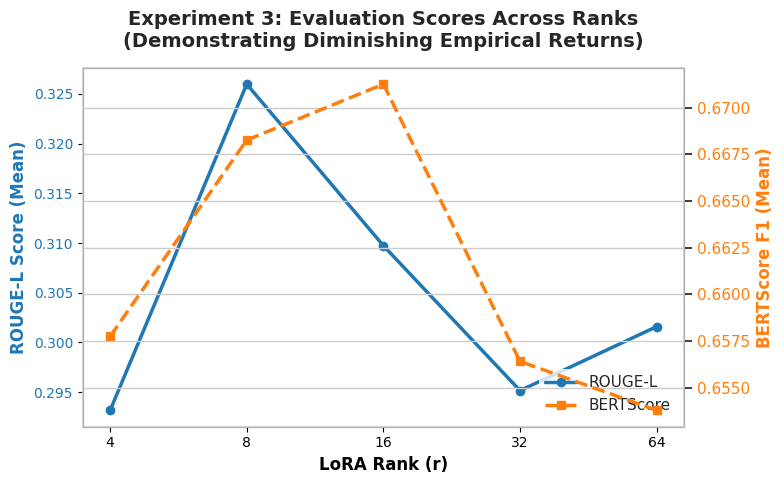

📊 Visualization successfully exported to: /content/drive/MyDrive/exp_3_rank_ablation/rank_ablation_curves.png


In [ ]:
# %% ==================== CELL 4: VISUALIZATION ====================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

summary_path = os.path.join("/content/drive/MyDrive/exp_3_rank_ablation", "exp_3_summary_statistics.csv")
if not os.path.exists(summary_path):
    print("Error: Summary statistics file not found. Ensure Cell 3 completes successfully first.")
else:
    df_plot = pd.read_csv(summary_path)

    fig, ax1 = plt.subplots(figsize=(8, 5))
    sns.set_theme(style="whitegrid")

    # Plot ROUGE-L on Left Axis
    color = '#1f77b4'
    ax1.set_xlabel('LoRA Rank (r)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('ROUGE-L Score (Mean)', color=color, fontsize=12, fontweight='bold')
    line1 = ax1.plot(df_plot['rank'], df_plot['rougeL_mean'], color=color, marker='o', linewidth=2.5, label='ROUGE-L')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xscale('log', base=2) # Adjust layout scale due to power-of-two ranks
    ax1.set_xticks(df_plot['rank'])
    ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())

    # Plot BERTScore on Right Axis
    ax2 = ax1.twinx()
    color = '#ff7f0e'
    ax2.set_ylabel('BERTScore F1 (Mean)', color=color, fontsize=12, fontweight='bold')
    line2 = ax2.plot(df_plot['rank'], df_plot['bertscore_mean'], color=color, marker='s', linewidth=2.5, linestyle='--', label='BERTScore')
    ax2.tick_params(axis='y', labelcolor=color)

    # Formatting and Legend Compilation
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower right', frameon=True, facecolor='white', edgecolor='none')

    plt.title('Experiment 3: Evaluation Scores Across Ranks\n(Demonstrating Diminishing Empirical Returns)', fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()

    # Save the output plot back into your permanent Drive
    plot_path = os.path.join("/content/drive/MyDrive/exp_3_rank_ablation", "rank_ablation_curves.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"📊 Visualization successfully exported to: {plot_path}")